In [3]:
install.packages("sqldf")
library(sqldf)

master <- read.csv("northstar_master_dataset.csv")

head(master)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite



,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,⋯,complaint_count,total_compensation,avg_resolution_days,incident_count,avg_resolved_hours,is_failed,has_complaint,has_incident,cost_per_km,high_risk_delivery
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>,<int>
1,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,⋯,0,0.00,NA,0,NA,0,0,0,0.5936210,0
2,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,Airport,Low,109.30,App,⋯,0,0.00,NA,0,NA,0,0,0,NA,0
3,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,Airport,High,33.50,Phone,⋯,1,8.66,2,0,NA,0,1,0,1.0092025,1
4,O00004,C0520,Parcel,2025-01-11 17:15:00,2,Riverside,North,Medium,10.04,App,⋯,0,0.00,NA,0,NA,0,0,0,1.2969052,0
5,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,South,Low,125.58,Phone,⋯,1,54.41,8,0,NA,0,1,0,0.8450968,1
6,O00006,C0437,Retail,2024-08-05 04:55:00,1,Central,East,High,151.44,Web,⋯,0,0.00,NA,0,NA,0,0,0,NA,0


In [4]:
query1 <- sqldf("
SELECT service_type, COUNT(order_id) AS total_orders
FROM master
GROUP BY service_type
ORDER BY total_orders DESC
")

query1

service_type,total_orders
<chr>,<int>
Passenger,341
Parcel,308
Retail,297
Business,165
Medical,139


In [5]:
query2 <- sqldf("
SELECT hub_name,
       COUNT(order_id) AS total_orders,
       SUM(is_failed) AS failed_orders,
       ROUND(AVG(is_failed) * 100, 2) AS failed_rate
FROM master
GROUP BY hub_name
ORDER BY failed_rate DESC
")

query2

hub_name,total_orders,failed_orders,failed_rate
<chr>,<int>,<int>,<dbl>
Midtown Relay,128,26,20.31
Central Core,115,23,20.00
Airport Hub,104,15,14.42
West Gate,127,16,12.60
North Exchange,136,17,12.50
Riverside Hub,115,14,12.17
South Link,106,10,9.43
East Dock,119,11,9.24
,300,0,0.00


In [6]:
query3 <- sqldf("
SELECT service_type,
       ROUND(AVG(fuel_or_charge_cost), 2) AS avg_cost,
       ROUND(AVG(cost_per_km), 2) AS avg_cost_per_km
FROM master
GROUP BY service_type
ORDER BY avg_cost DESC
")

query3

service_type,avg_cost,avg_cost_per_km
<chr>,<dbl>,<dbl>
Business,13.14,1.24
Parcel,13.08,1.29
Retail,12.97,1.23
Medical,12.77,1.41
Passenger,12.40,1.21


In [7]:
query4 <- sqldf("
SELECT service_type,
       COUNT(order_id) AS total_orders,
       SUM(has_complaint) AS complaint_orders,
       ROUND(AVG(has_complaint) * 100, 2) AS complaint_rate
FROM master
GROUP BY service_type
ORDER BY complaint_rate DESC
")

query4

service_type,total_orders,complaint_orders,complaint_rate
<chr>,<int>,<int>,<dbl>
Retail,297,72,24.24
Medical,139,33,23.74
Passenger,341,77,22.58
Parcel,308,69,22.40
Business,165,34,20.61


In [8]:
query5 <- sqldf("
SELECT order_id, service_type, hub_name, delivery_status,
       complaint_count, incident_count, fuel_or_charge_cost,
       customer_rating_post_delivery
FROM master
WHERE high_risk_delivery = 1
ORDER BY fuel_or_charge_cost DESC
LIMIT 10
")

query5

order_id,service_type,hub_name,delivery_status,complaint_count,incident_count,fuel_or_charge_cost,customer_rating_post_delivery
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
O00672,Retail,Riverside Hub,OnTime,0,1,29.43,4.06
O00430,Retail,Riverside Hub,Failed,1,0,25.46,3.36
O01011,Business,East Dock,Failed,0,0,25.09,1.71
O00554,Medical,Midtown Relay,Delayed,0,2,24.54,2.52
O00128,Medical,Riverside Hub,Delayed,1,1,24.27,2.68
O00282,Parcel,Central Core,Delayed,1,1,23.60,NA
O01095,Business,West Gate,OnTime,0,1,22.66,3.89
O00765,Retail,Central Core,Failed,1,0,22.61,2.40
O00801,Retail,South Link,OnTime,2,0,22.20,4.79


In [9]:
install.packages("ggplot2")
library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



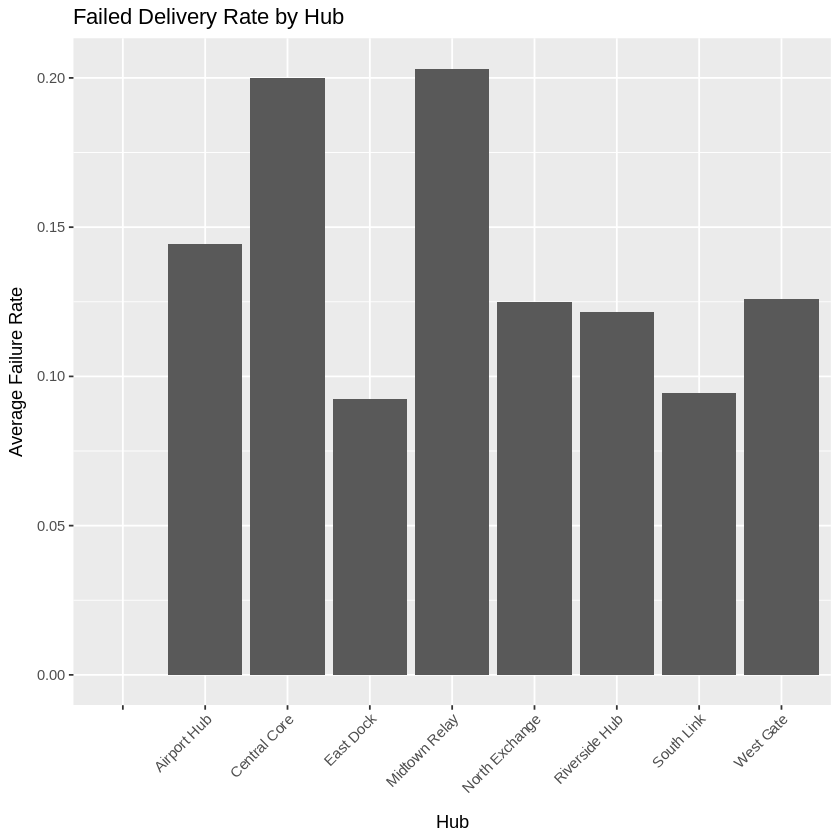

In [10]:
ggplot(master, aes(x = hub_name, y = is_failed)) +
  stat_summary(fun = mean, geom = "bar") +
  labs(title = "Failed Delivery Rate by Hub",
       x = "Hub",
       y = "Average Failure Rate") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

Warning message:
“Removed 300 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


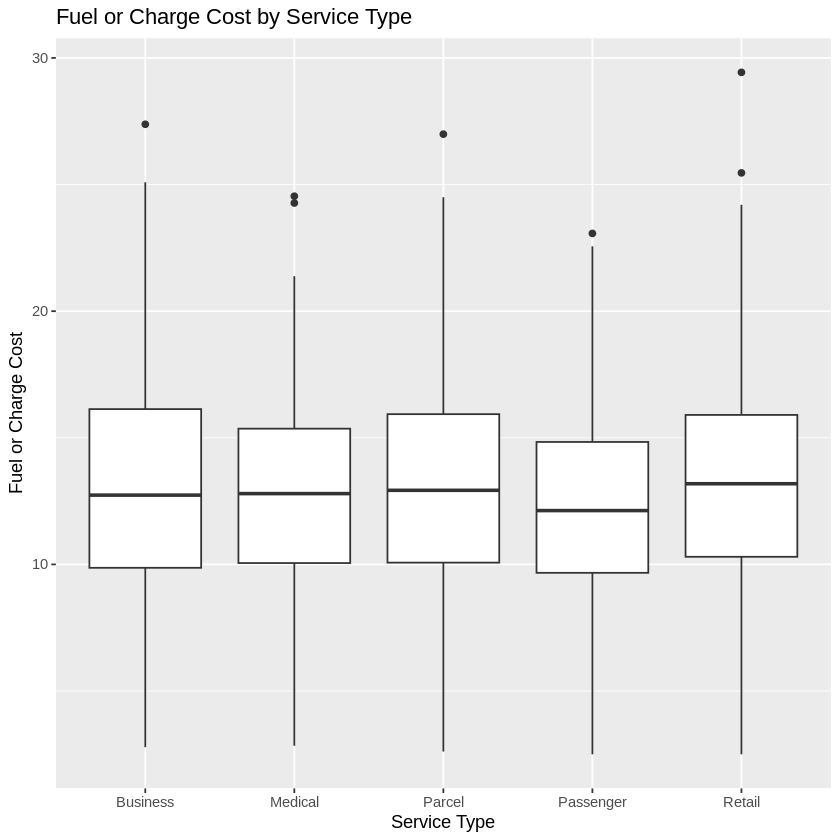

In [11]:
ggplot(master, aes(x = service_type, y = fuel_or_charge_cost)) +
  geom_boxplot() +
  labs(title = "Fuel or Charge Cost by Service Type",
       x = "Service Type",
       y = "Fuel or Charge Cost")

Warning message:
“Removed 314 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


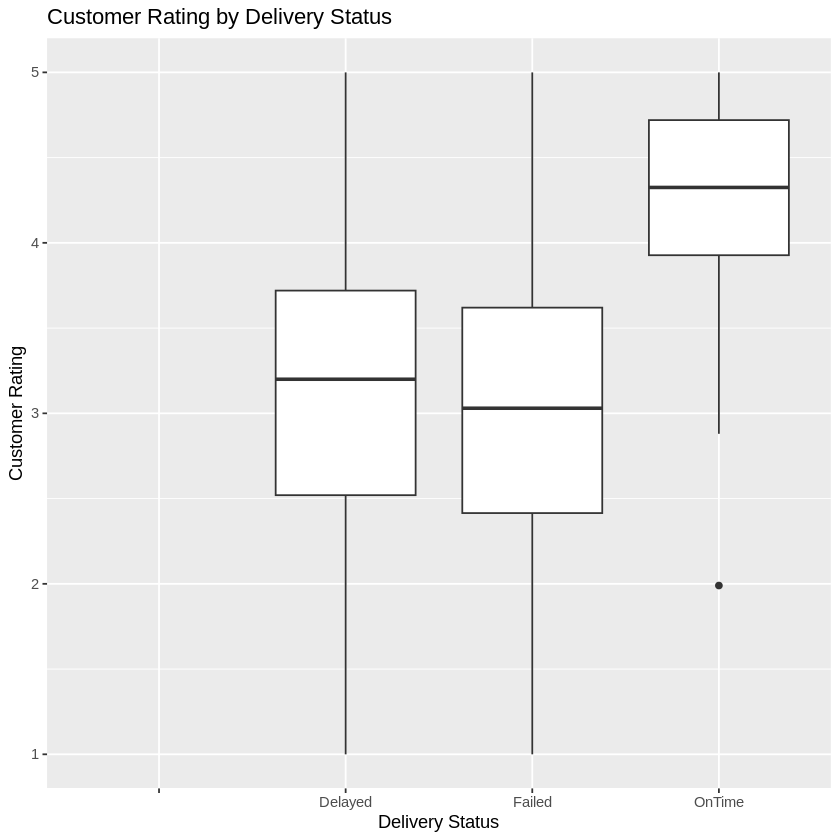

In [12]:
ggplot(master, aes(x = delivery_status, y = customer_rating_post_delivery)) +
  geom_boxplot() +
  labs(title = "Customer Rating by Delivery Status",
       x = "Delivery Status",
       y = "Customer Rating")